In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [14]:
df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

In [15]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


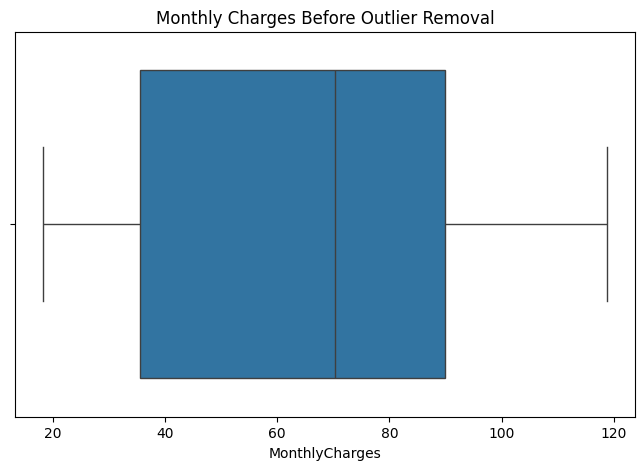

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["MonthlyCharges"]
)

plt.title("Monthly Charges Before Outlier Removal")
plt.show()

In [17]:
Q1 = df["MonthlyCharges"].quantile(0.25)
Q3 = df["MonthlyCharges"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["MonthlyCharges"] >= lower) &
    (df["MonthlyCharges"] <= upper)
]

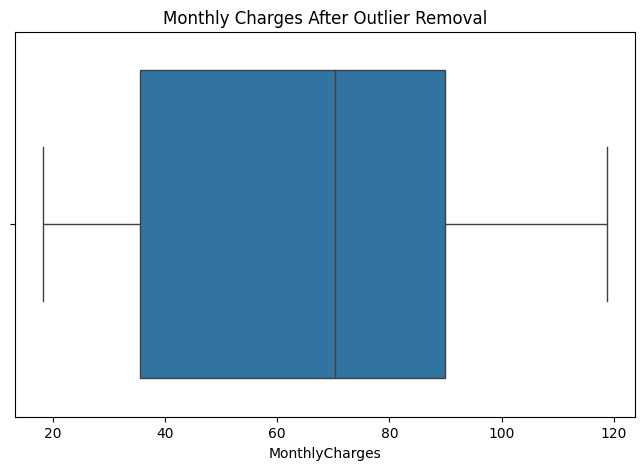

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["MonthlyCharges"]
)

plt.title("Monthly Charges After Outlier Removal")
plt.show()

In [19]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] /
    (df["tenure"] + 1)
)

In [20]:
df["LongTermCustomer"] = (
    df["tenure"] >= 24
).astype(int)

In [21]:
df["ContractRisk"] = (
    df["Contract"] == "Month-to-month"
).astype(int)

In [22]:
service_cols = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = 0

for col in service_cols:
    df["ServiceCount"] += (
        df[col] == "Yes"
    ).astype(int)

In [23]:
df["SecuritySupportScore"] = (
    (df["OnlineSecurity"] == "Yes").astype(int)
    +
    (df["TechSupport"] == "Yes").astype(int)
)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000000,1.000
tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000000,72.000
MonthlyCharges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850000,118.750
TotalCharges,7043.0,2281.916928,2265.270398,18.800000,402.225000,1397.475,3786.600000,8684.800
AvgMonthlySpend,7043.0,61.173413,61.019723,9.183333,26.274411,61.150,84.940047,1397.475
LongTermCustomer,7043.0,0.557575,0.496709,0.000000,0.000000,1.000,1.000000,1.000
ContractRisk,7043.0,0.550192,0.497510,0.000000,0.000000,1.000,1.000000,1.000
ServiceCount,7043.0,3.362914,2.062031,0.000000,1.000000,3.000,5.000000,8.000
SecuritySupportScore,7043.0,0.576885,0.745822,0.000000,0.000000,0.000,1.000000,2.000


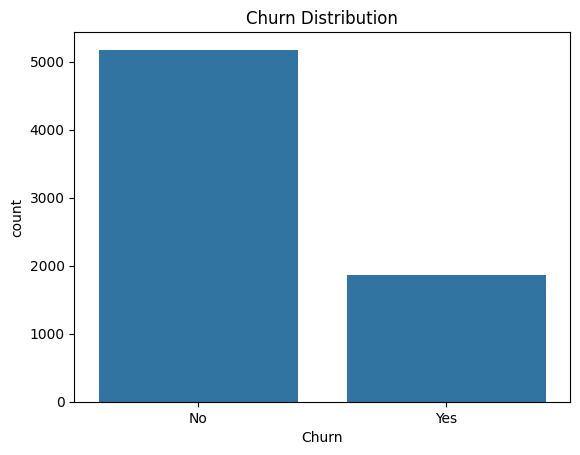

In [25]:
sns.countplot(
    x="Churn",
    data=df
)

plt.title("Churn Distribution")
plt.show()

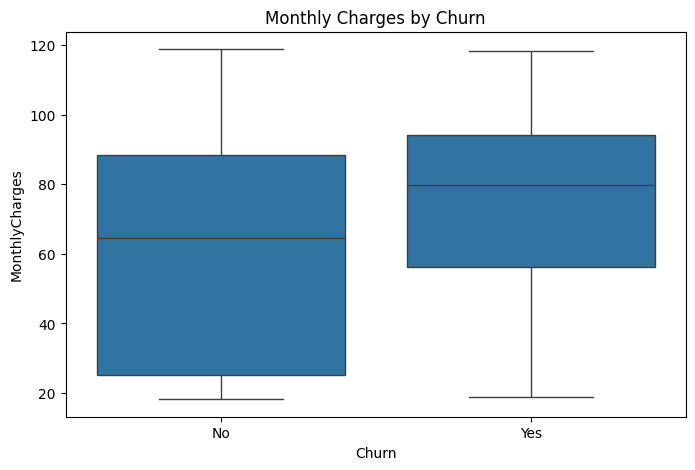

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges by Churn")
plt.show()

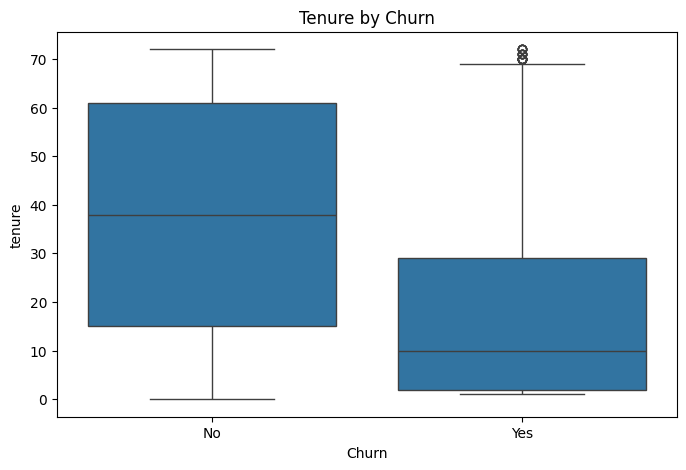

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure by Churn")
plt.show()

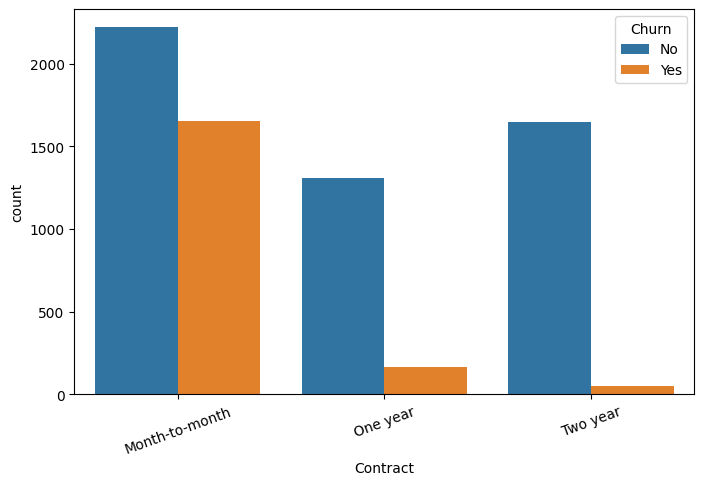

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.xticks(rotation=20)
plt.show()

In [29]:
df["ChurnBinary"] = (
    df["Churn"] == "Yes"
).astype(int)

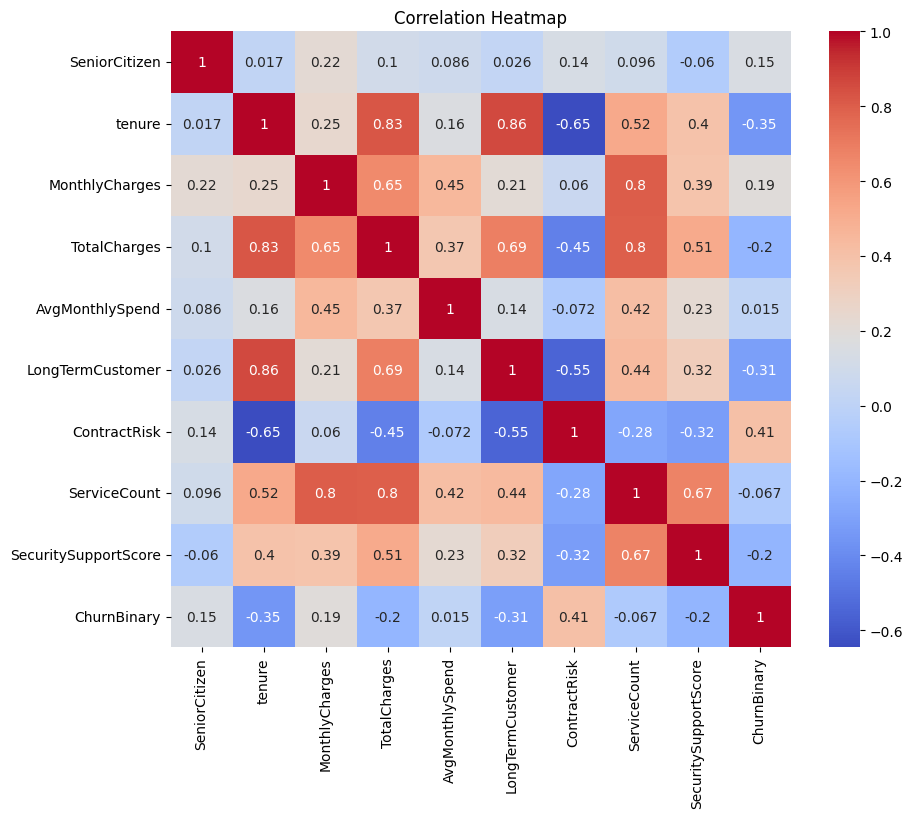

In [30]:
corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "LongTermCustomer",
    "ContractRisk",
    "ServiceCount",
    "SecuritySupportScore",
    "ChurnBinary"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [31]:
segment_data = df[
    [
        "TotalCharges",
        "MonthlyCharges",
        "tenure"
    ]
]

In [32]:
scaler_seg = StandardScaler()

segment_scaled = scaler_seg.fit_transform(
    segment_data
)

In [33]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(
    segment_scaled
)

In [34]:
cluster_value = (
    df.groupby("Cluster")
    ["TotalCharges"]
    .mean()
)

sorted_clusters = (
    cluster_value
    .sort_values()
    .index
)

mapping = {
    sorted_clusters[0]: "Low Value",
    sorted_clusters[1]: "Medium Value",
    sorted_clusters[2]: "High Value"
}

df["CustomerSegment"] = (
    df["Cluster"]
    .map(mapping)
)

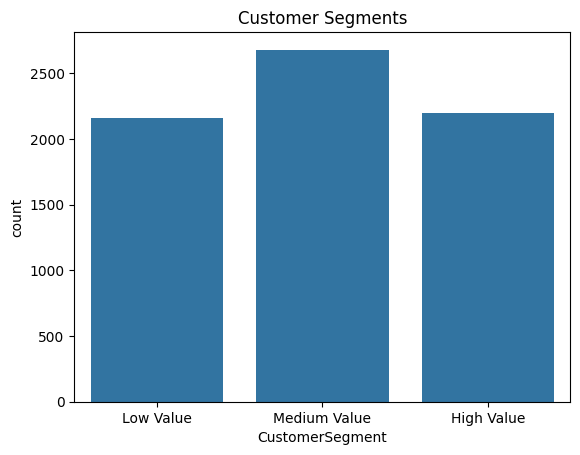

In [35]:
sns.countplot(
    x="CustomerSegment",
    data=df
)

plt.title("Customer Segments")
plt.show()

In [36]:
df["Churn"] = (
    df["Churn"] == "Yes"
).astype(int)

In [37]:
X = pd.get_dummies(
    df.drop(
        columns=[
            "customerID",
            "Churn",
            "Cluster",
            "CustomerSegment"
        ]
    ),
    drop_first=True
)

y = df["Churn"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

In [41]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [42]:
def evaluate(y_true,pred,prob):

    return {
        "Accuracy": accuracy_score(y_true,pred),
        "Precision": precision_score(y_true,pred),
        "Recall": recall_score(y_true,pred),
        "F1": f1_score(y_true,pred),
        "ROC-AUC": roc_auc_score(y_true,prob)
    }

In [43]:
lr_results = evaluate(
    y_test,
    lr_pred,
    lr_prob
)

rf_results = evaluate(
    y_test,
    rf_pred,
    rf_prob
)

print(lr_results)
print(rf_results)

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC-AUC': np.float64(1.0)}
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'ROC-AUC': np.float64(1.0)}


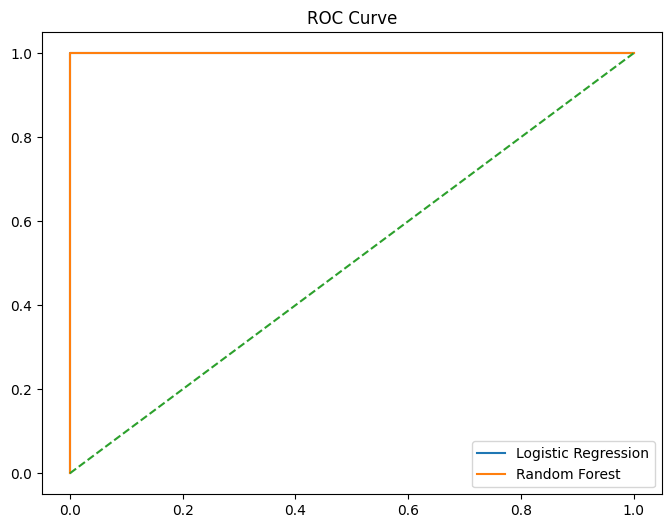

In [44]:
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    lr_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr,tpr_lr,label="Logistic Regression")
plt.plot(fpr_rf,tpr_rf,label="Random Forest")

plt.plot([0,1],[0,1],"--")

plt.legend()
plt.title("ROC Curve")

plt.show()

In [45]:
all_prob = rf.predict_proba(X)[:,1]

df["ChurnProbability"] = all_prob

In [46]:
def risk_category(prob):

    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

df["RiskCategory"] = (
    df["ChurnProbability"]
    .apply(risk_category)
)

In [47]:
high_risk = df[
    df["RiskCategory"] == "High Risk"
]

high_risk.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,AvgMonthlySpend,LongTermCustomer,ContractRisk,ServiceCount,SecuritySupportScore,ChurnBinary,Cluster,CustomerSegment,ChurnProbability,RiskCategory
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,36.050000,0,1,3,1,1,0,Medium Value,0.914390,High Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,50.550000,0,1,1,0,1,0,Medium Value,0.945122,High Risk
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,91.166667,0,1,5,0,1,0,Medium Value,0.978425,High Risk
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,105.036207,1,1,6,1,1,0,Medium Value,0.922703,High Risk
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,100.726000,1,1,6,0,1,1,High Value,0.912338,High Risk


In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

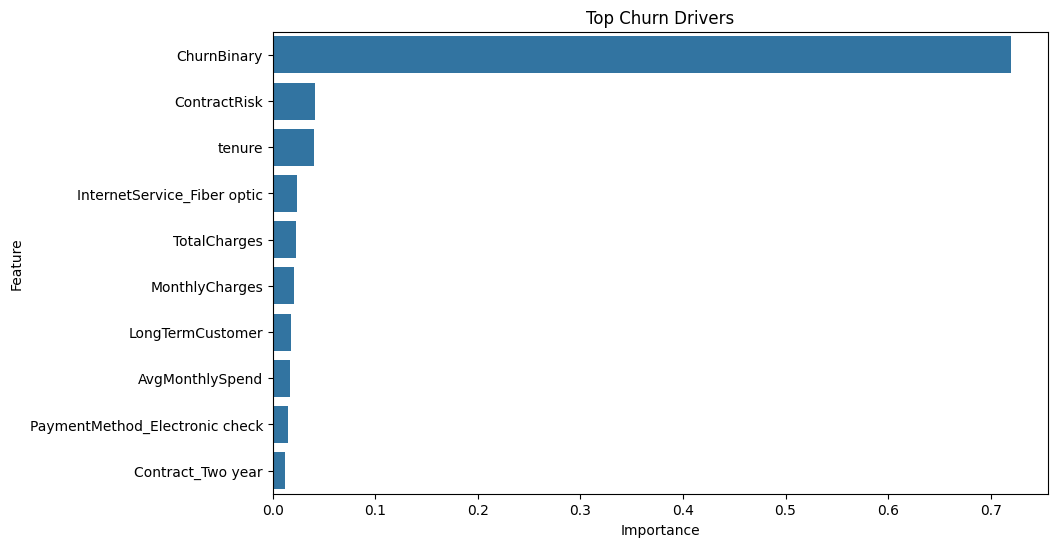

In [49]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top Churn Drivers")
plt.show()

In [50]:
revenue_at_risk = (
    df[
        df["RiskCategory"] == "High Risk"
    ]["MonthlyCharges"]
    .sum()
)

print(
    f"Potential Monthly Revenue At Risk: ${revenue_at_risk:,.2f}"
)

Potential Monthly Revenue At Risk: $139,130.85


In [51]:
df.to_csv(
    "Customer_Churn_Predictions.csv",
    index=False
)

importance.to_csv(
    "Feature_Importance.csv",
    index=False
)

In [52]:
import pickle

pickle.dump(
    rf,
    open("churn_model.pkl","wb")
)

pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)